A parametric model of circumstellar disks 
---
See e.g. section 3.1 in https://ui.adsabs.harvard.edu/abs/2014ApJ...788...59W/abstract

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import functools
import emcee, corner
from collections import OrderedDict

os.environ['CUDA_VISIBLE_DEVICES'] = '3,4'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference
from network import shard
from consts import *

In [2]:
def render_cube(projection, disk, nd_co, temperature, velocity_az, bbox):
    pixel_area = (projection.fov/projection.npix)**2       # pixel area to convert radiances to Jy 
    ray_coords, obs_dir = sensor.orthographic_disk_projection(projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
                                                              projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max)
    ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)
    print('line frequency: {} Ghz'.format(nu0/ghz))

    # Compute line radiative transfer for a whole spectral cube
    # Compute spectral width scaled by the local isothermal sounds speed c_s=2kT/(mu*m_h)
    freqs = sensor.compute_camera_freqs(projection.linelam, projection.width_kms, nu0)
    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t, disk.m_mol)

    print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_vmap(freqs, gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(projection.linelam, projection.npix, projection.npix)
    return images, freqs

def plot_spectral_cube(fig, axes, images, fov, title=None, vmax=None, beamsize=None, cbar_width=0.02):
    if not (beamsize is None):
        x_c = y_c = -.4*fov
        gaussian = sensor.make_gaussian(images.shape[-1], fov_rad, beamsize, beamsize, 0, 1, x_c, y_c)
            
    for ax, image in zip(axes, images):
        im = ax.imshow(image, vmax=vmax, origin='lower')
        if not (beamsize is None):
            cp = ax.contour(gaussian, levels=[0.5*np.max(gaussian)], colors='w', linewidths=1.0)
        ax.axis('off')
    fig.subplots_adjust(left=0.01, wspace=0)
    axes[int(len(axes)/2)-1].set_title(title)
    cax = fig.add_axes([axes[0].get_position().x0, axes[0].get_position().y0-0.05, axes[-1].get_position().x1-axes[0].get_position().x0, cbar_width])
    fig.colorbar(im, cax=cax, location='bottom')

def dump_yaml(out_dir, params):
    # Dump parameters
    yaml = YAML(typ='safe')
    yaml.default_flow_style = False

    yaml_dict = params.copy()
    for model in ['disk', 'projection']:
        for key in yaml_dict[model]:
            # replace numpy with generic python
            if isinstance(yaml_dict[model][key], np.float64):
                yaml_dict[model][key] = float(yaml_dict[model][key])
                
    with open(out_dir.joinpath('params.yaml'), 'w') as file:
        yaml.dump(yaml_dict, file)

# Define a parametric ground truth model and render frequency cubes


In [42]:
disk = parametric_disk.DiskFlaherty(
    name='HD163296_Fiducial',
    v_turb=0.031,
    T_mid1=21.8,
    T_atm1=86.3,
    q=-0.278,
    M_star=2.3*M_sun,
    gamma=1.0,
    r_in=9.0,
    r_c=175.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79*1.59e21,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
    transition=3,
    m_mol=2.37*m_h
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, disk.r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

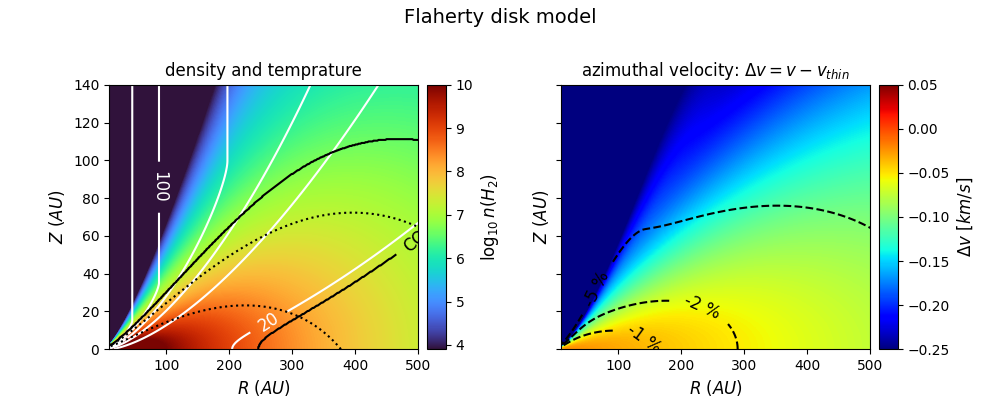

In [43]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[5e-5], colors='black')
axes[0].clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [44]:
distance = 122*pc          # distance
fov_as  = 14.0
fov_rad =  fov_as*arcsec   # field of view (RA/Dec) 
fov = 2 * distance * np.tan(fov_rad/2.0)  # 1611 [au]
projection = sensor.Projection(
    name=disk.name,
    npix=384,
    nray=100,
    incl=48.0,
    phi=0.0,
    posang=312.0,
    fov=fov,
    r_min=100*au,
    r_max=1000.0*au,
    theta_min=0.0,
    theta_max=np.pi,
    linelam=10,
    width_kms=3.8,
    v_sys=5.102,
)

# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

# Render spectral cube and convolve with gaussian beam
images, freqs = render_cube(projection, disk, nd_co, temperature, velocity_az, bbox_disk)

beamsize = 0.3 * arcsec
beam = sensor.gaussian_beam(projection.npix, fov_rad, beamsize)
images_blurred = sensor.fftconvolve_vmap(images, beam)

line frequency: 345.7959899 Ghz
computing spectral cube for a total of 10 frequencies


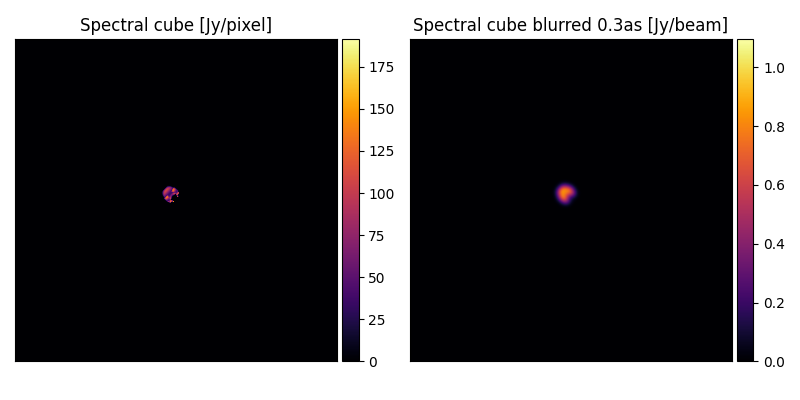

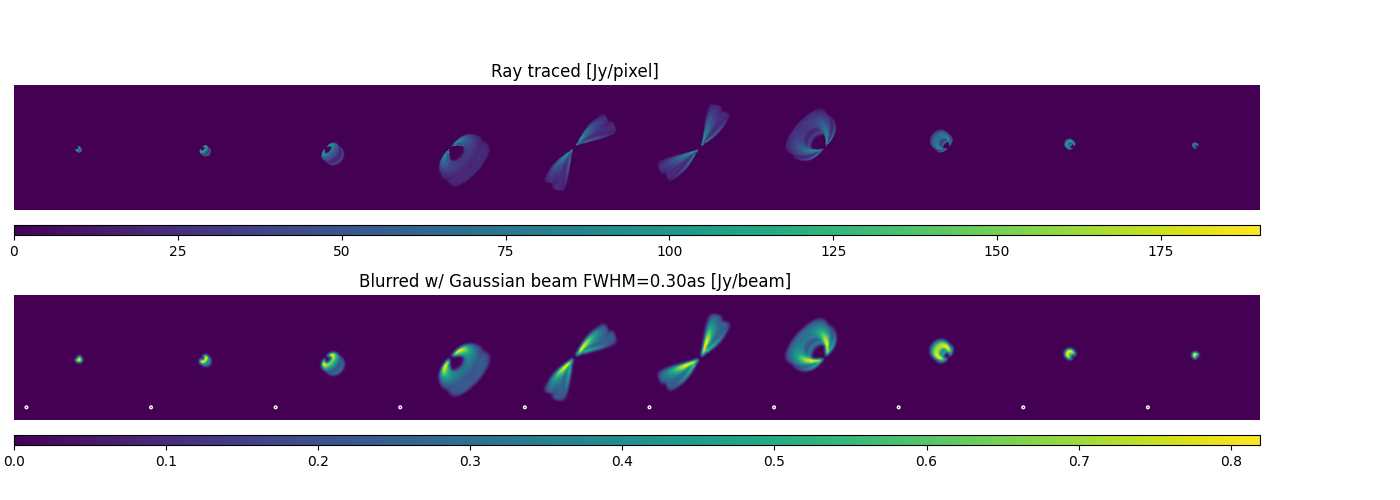

In [47]:
# Save and plot outputs
out_dir = Path('../data/parametric_disk/').joinpath(disk.name)
out_dir.mkdir(parents=True, exist_ok=True)

params = {
    'desc': 'parametric circumstellar model',
    'disktype': '{}'.format(type(disk).__name__),
    'disk': disk.__dict__, 
    'projection': projection.__dict__
}
dump_yaml(out_dir, params)
np.savez(out_dir.joinpath('disk.npz'), nd_co=nd_co, temperature=temperature, velocity_az=velocity_az)
np.savez(out_dir.joinpath('data.npz'), images=images, images_blurred=images_blurred, beam=beam, beamsize=beamsize, freqs=freqs)
np.savez(out_dir.joinpath('grid.npz'), z_disk=z_disk, r_disk=r_disk)

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
titles = ['Spectral cube [Jy/pixel]', 'Spectral cube blurred {}as [Jy/beam]'.format(beamsize/arcsec)]
visualization.animate_movies_synced([images, np.array(images_blurred)], axes, vmin=[0,0], titles=titles, cmaps='inferno', output=out_dir.joinpath('observed_cube.gif'), fps=2)

fig, axes = plt.subplots(2, 10, figsize=(14, 5), sharey=True, sharex=True)
plot_spectral_cube(fig, axes[0], images, fov_rad, 'Ray traced [Jy/pixel]')
plot_spectral_cube(fig, axes[1], images_blurred, fov_rad, 'Blurred w/ Gaussian beam FWHM={:1.2f}as [Jy/beam]'.format(beamsize/arcsec), beamsize=beamsize)
fig.savefig(out_dir.joinpath('observed_cube.pdf'), bbox_inches='tight')

# Parameter inference using `emcee`

In [3]:
# Load saved model
model_path = Path('../data/parametric_disk/HD163296_Fiducial/')

yaml = YAML(typ='safe')
with open(model_path.joinpath('params.yaml'), 'r') as stream:
    params = yaml.load(stream)
disk = getattr(parametric_disk, params['disktype'])(**params['disk'])
projection = sensor.Projection(**params['projection'])

# Load data and ground truth fields for comparison
images, images_blurred, beam, beamsize, freqs = np.load(model_path.joinpath('data.npz')).values()
nd_co, temperature, velocity_az = np.load(model_path.joinpath('disk.npz')).values()
z_disk, r_disk = np.load(model_path.joinpath('grid.npz')).values()
bbox_disk = jnp.array([(au*z_disk.min(), au*z_disk.max()), (au*r_disk.min(), au*r_disk.max())])

# Add noise to the observations 
sigma = 2e-3 # mJy
noise = np.random.normal(0, sigma, size=images_blurred.shape)
observed_cube = images_blurred + noise

## Single parameter estimation (v_turb)

In [4]:
@jax.tree_util.register_pytree_node_class
class TurbSampler(object):
    def __init__(self, freqs, gas_v, cs_sq, alpha_therm_sq, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, 
                 obs_dir, nu0, pixel_area, beam, x_bounds, sigma):
        self.freqs = freqs
        self.gas_v = gas_v
        self.cs_sq = cs_sq
        self.alpha_therm_sq = alpha_therm_sq
        self.n_up = n_up
        self.n_dn = n_dn
        self.a_ud = a_ud
        self.b_ud = b_ud
        self.b_du = b_du
        self.ray_coords = ray_coords
        self.obs_dir = obs_dir
        self.nu0 = nu0
        self.pixel_area = pixel_area
        self.beam = beam
        self.x_bounds = x_bounds
        self.sigma = sigma
        
    def logprior_fn(self, x):
        condition = jnp.logical_and(x>=self.x_bounds[0],x<=self.x_bounds[1])
        return jnp.where(condition, 0, -jnp.inf)

    def loglikelihood_fn(self, x, y):
        alpha_tot = jnp.sqrt(self.alpha_therm_sq + cs_sq*x**2)
        model = jnp.nan_to_num(
            line_rte.compute_spectral_cube(self.freqs, self.gas_v, alpha_tot, self.n_up, 
                                           self.n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, 
                                           self.obs_dir, self.nu0, self.pixel_area)
        )
        model = sensor.fftconvolve_vmap(model, beam)
        logpdf = jsp.stats.norm.logpdf(y, model, self.sigma)
        return jnp.sum(logpdf)
        
    @jax.jit
    def logprobability_fn(self, x, y):
        return self.logprior_fn(x) + self.loglikelihood_fn(x, y)
    
    def tree_flatten(self):
        children = (self.freqs, self.gas_v, self.cs_sq, self.alpha_therm_sq, 
                    self.n_up, self.n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, 
                    self.obs_dir, self.nu0, self.pixel_area, self.beam, self.x_bounds, self.sigma)
        aux_data = {}  # static values
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)

In [5]:
pixel_area = (projection.fov/projection.npix)**2
ray_coords, obs_dir = sensor.orthographic_disk_projection(projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
                                                          projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max)
ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

# Interpolate dataset along the ray coordinates
gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox_disk)
gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox_disk, cval=1e-10)
gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox_disk)
gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)
print('line frequency: {} Ghz'.format(nu0/ghz))

# Width of the spectral line depends on the thermal width and is scaled to the local sounds speed
alpha_therm_sq = 2*kk*gas_t/m_co
cs_sq = 2*kk*gas_t/disk.m_mol

turb_sampler = TurbSampler(
    freqs, gas_v, cs_sq, alpha_therm_sq, n_up, n_dn, a_ud, b_ud, b_du, 
    ray_coords, obs_dir, nu0, pixel_area, beam, 
    x_bounds=[0.0, np.inf],
    sigma=sigma
)

line frequency: 345.7959899 Ghz


In [6]:
ndim, nwalkers = 1, 20
p0 = np.random.uniform(0, 1, (nwalkers, ndim))
sampler = emcee.EnsembleSampler(nwalkers, ndim, turb_sampler.logprobability_fn, args=[observed_cube])
state = sampler.run_mcmc(p0, 500, progress=True)

 37%|█████████████████████████████████████████████████████▋                                                                                            | 184/500 [07:53<13:32,  2.57s/it]


KeyboardInterrupt: 

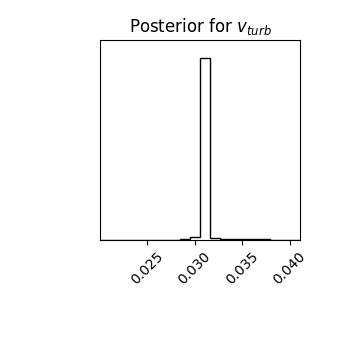

In [7]:
%matplotlib widget
fig = corner.corner(np.array(sampler.get_chain(discard=50, flat=True)))
plt.title(r'Posterior for $v_{turb}$');

## Multiple parameter estimation

In [4]:
# Projection geometry
pixel_area = (projection.fov/projection.npix)**2
ray_coords, obs_dir = sensor.orthographic_disk_projection(
    projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
    projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max
)
ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)

In [5]:
posterior_params = OrderedDict(
    v_turb={'bounds': [0.0, np.inf], 'p0_range': [0 ,1]},
    q={'bounds': [-np.inf, 0], 'p0_range': [-0.5 ,0]},
    r_c={'bounds': [0, np.inf], 'p0_range': [100 ,300]},
    T_atm1={'bounds': [0, np.inf], 'p0_range': [60 ,120]},
    T_mid1={'bounds': [0, np.inf], 'p0_range': [10 ,30]}
)

# Initialize the sampler
disk_sampler = inference.DiskSampler(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, sigma, disk, posterior_params
)

ndim, nwalkers = len(posterior_params), 20
p0 = disk_sampler.sample_p0(posterior_params, nwalkers, seed=42)

# Set up the backend
filename = model_path.joinpath('recovery/mcmc_sampler.h5')
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, disk_sampler.logprob, args=[observed_cube, freqs], backend=backend)

setting inital seed to: 42


In [18]:
state = sampler.run_mcmc(p0, 1000, progress=True)

line frequency: Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)> Ghz


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [53:10<00:00,  3.19s/it]


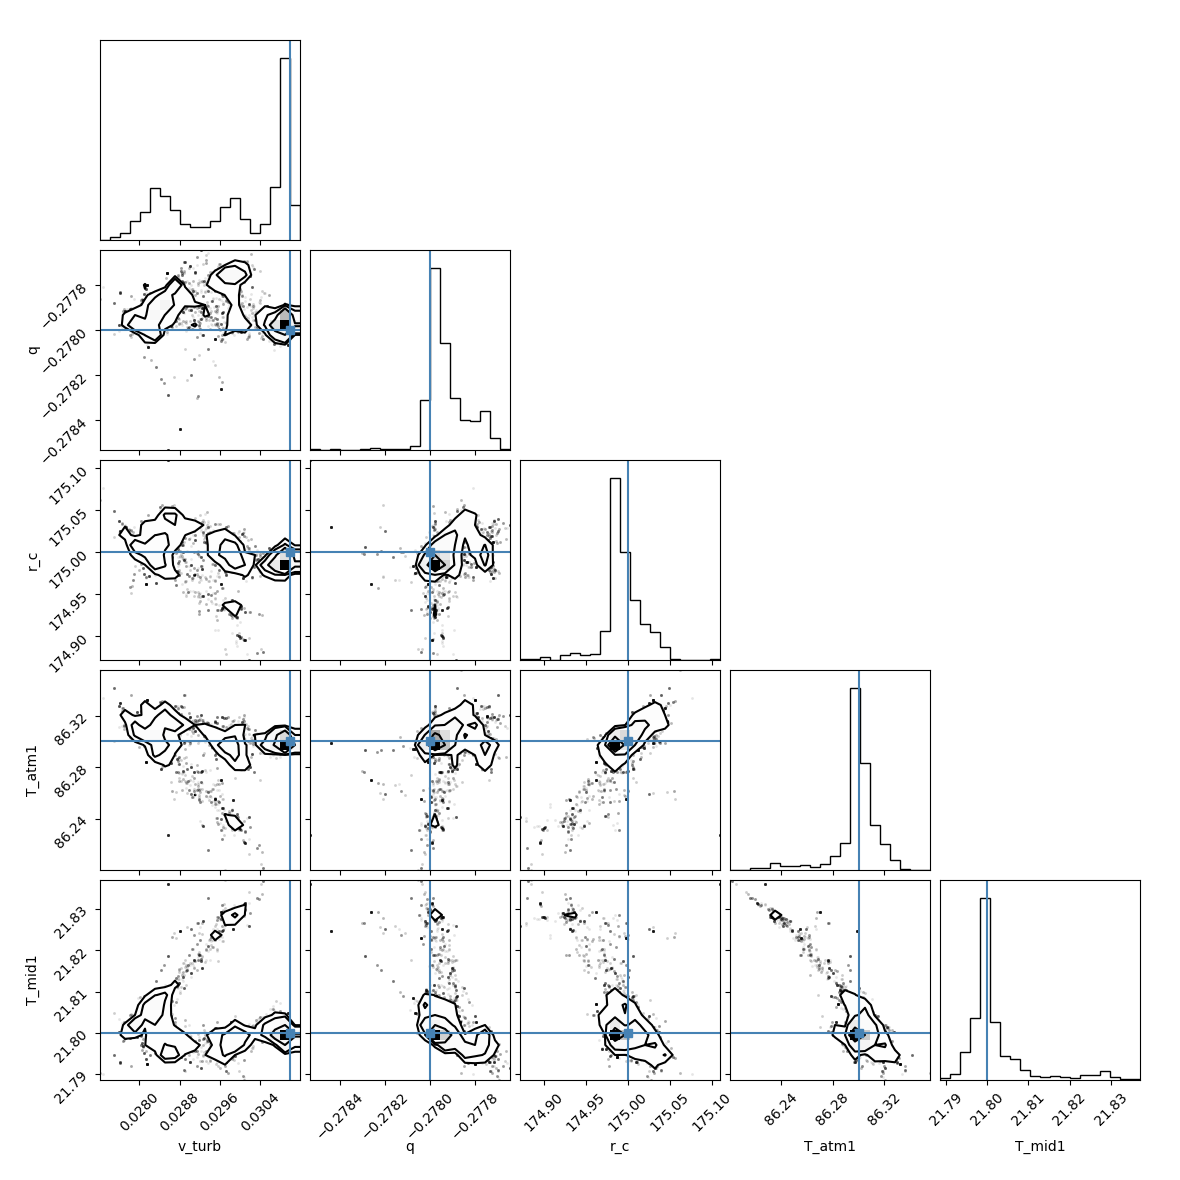

In [32]:
%matplotlib widget
fig = corner.corner(
    data=sampler.get_chain(discard=500, flat=True),
    labels=disk_sampler.param_names,
    truths=[params['disk'][key] for key in disk_sampler.param_names]
)